In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from spmd_reflection.cli import run, run_tx_sweep
from spmd_reflection.postprocess.masks import (tci_il_mask, tci_rl_mask,
                                               mpi_il_mask, mpi_rl_mask,
                                               check_tci_il, check_tci_rl,
                                               check_mpi_il, check_mpi_rl,
                                               check_ms_il)

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "lines.linewidth": 1.5,
    "font.size": 11})

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
CONFIG_PATH = PROJECT_ROOT / "config.yaml"

In [2]:
results = run(CONFIG_PATH)

freqs_hz  = results.frequency_hz
freqs_mhz = freqs_hz / 1e6

n_rx = results.il_phy_db.shape[1]
n_drops = results.il_tci_db.shape[1]

print(f"Frequenzbereich: {freqs_mhz[0]:.2f} – {freqs_mhz[-1]:.2f} MHz")
print(f"Anzahl Drops gesamt: {n_drops}")
print(f"Anzahl RX-Drops: {n_rx}")

Frequenzbereich: 0.30 – 40.00 MHz
Anzahl Drops gesamt: 3
Anzahl RX-Drops: 2


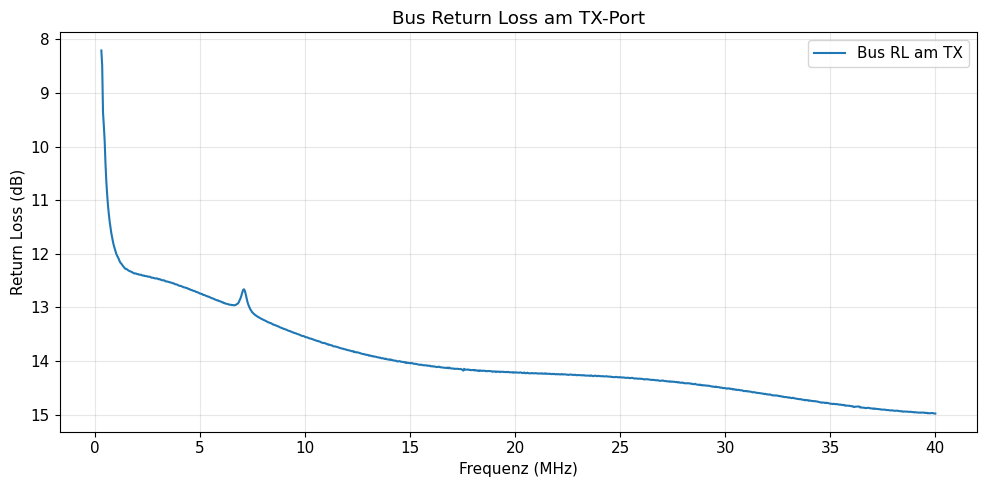

In [3]:
fig, ax = plt.subplots()

ax.plot(freqs_mhz, results.rl_db, label="Bus RL am TX")
ax.set_xlabel("Frequenz (MHz)")
ax.set_ylabel("Return Loss (dB)")
ax.set_title("Bus Return Loss am TX-Port")
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

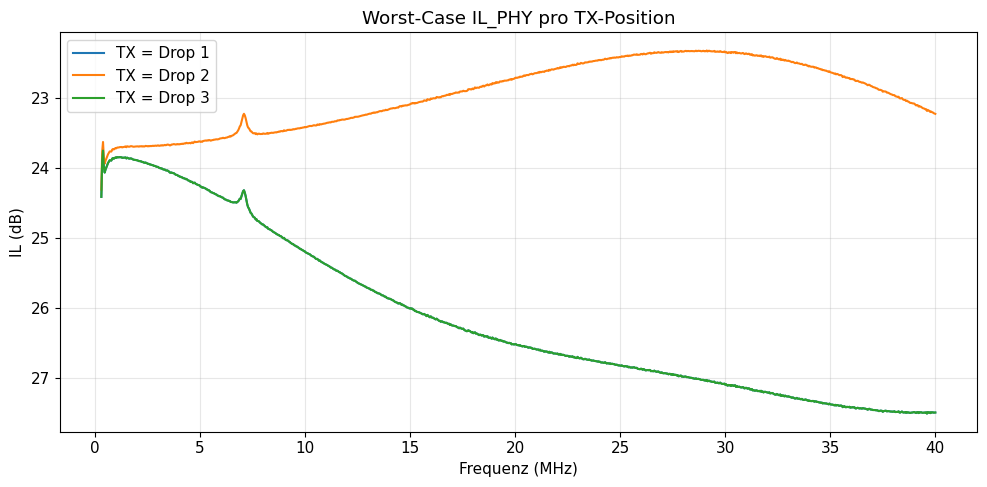

In [4]:
sweep = run_tx_sweep(CONFIG_PATH)

# Worst-Case IL_PHY über alle TX-Positionen
fig, ax = plt.subplots()
for tx_idx, bus in enumerate(sweep):
    if bus.il_phy_db.shape[1] > 0:
        worst_case = bus.il_phy_db.max(axis=1)
        ax.plot(freqs_mhz, worst_case, label=f"TX = Drop {tx_idx+1}")

ax.invert_yaxis()
ax.set_xlabel("Frequenz (MHz)")
ax.set_ylabel("IL (dB)")
ax.set_title("Worst-Case IL_PHY pro TX-Position")
ax.legend()
plt.tight_layout()
plt.show()

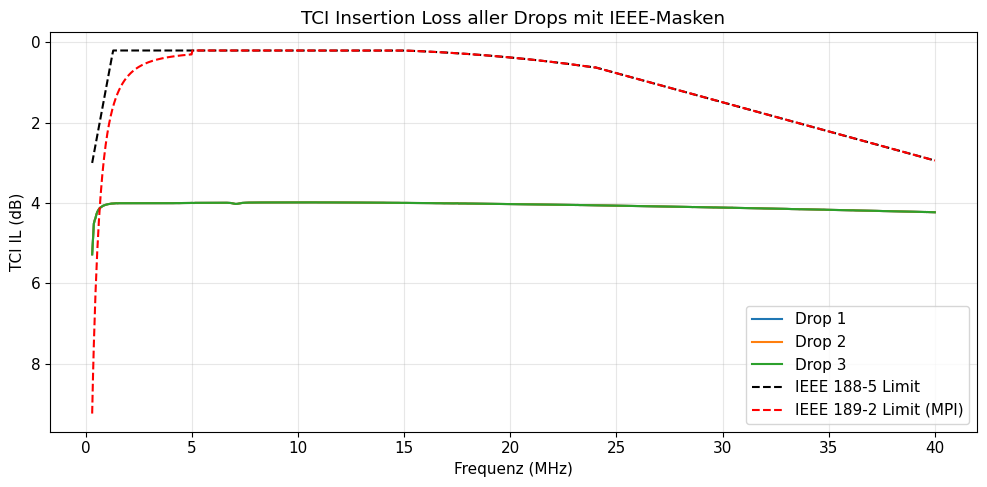

Drop 1: IL 188-5 ✗  IL 189-2 ✗
Drop 2: IL 188-5 ✗  IL 189-2 ✗
Drop 3: IL 188-5 ✗  IL 189-2 ✗


In [ ]:
il_limit_188 = tci_il_mask(freqs_hz)
il_limit_189 = mpi_il_mask(freqs_hz)

fig, ax = plt.subplots()

for i in range(n_drops):
    ax.plot(freqs_mhz, results.il_tci_db[:, i], label=f"Drop {i+1}")

ax.plot(freqs_mhz, il_limit_188, "k--", label="IEEE 188-5 Limit")
ax.plot(freqs_mhz, il_limit_189, "r--", label="IEEE 189-2 Limit (MPI)")

ax.set_xlabel("Frequenz (MHz)")
ax.set_ylabel("TCI IL (dB)")
ax.set_title("TCI Insertion Loss aller Drops")
ax.invert_yaxis()
ax.legend()
plt.tight_layout()
plt.show()

# Konformitäts-Check
ok_188 = check_tci_il(freqs_hz, results.il_tci_db)
ok_189 = check_mpi_il(freqs_hz, results.il_tci_db)
for i in range(n_drops):
    print(f"Drop {i+1}: IL 188-5 {'✓' if ok_188[:, i].all() else '✗'}  "
          f"IL 189-2 {'✓' if ok_189[:, i].all() else '✗'}")

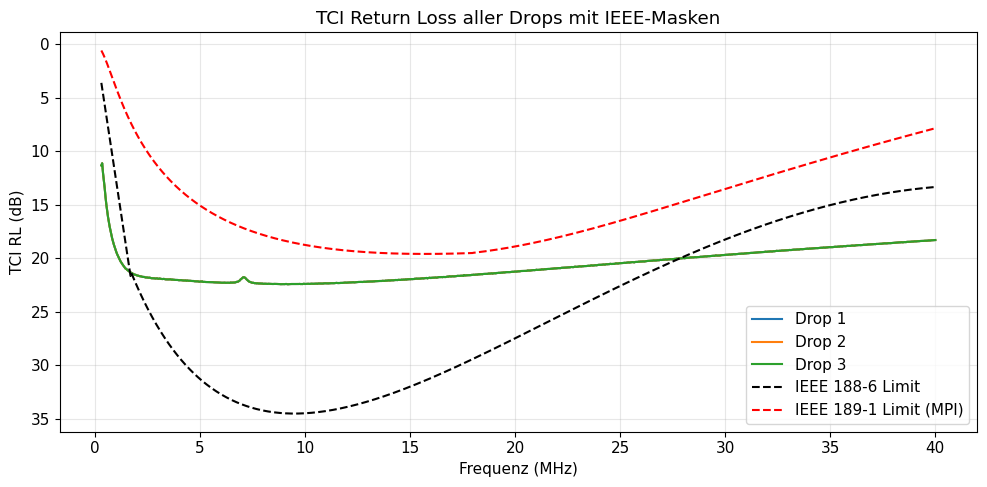

Drop 1: RL 188-6 ✗  RL 189-1 ✓
Drop 2: RL 188-6 ✗  RL 189-1 ✓
Drop 3: RL 188-6 ✗  RL 189-1 ✓


In [ ]:
rl_limit_188 = tci_rl_mask(freqs_hz)
rl_limit_189 = mpi_rl_mask(freqs_hz)

fig, ax = plt.subplots()

for i in range(n_drops):
    ax.plot(freqs_mhz, results.rl_tci_db[:, i], label=f"Drop {i+1}")

ax.plot(freqs_mhz, rl_limit_188, "k--", label="IEEE 188-6 Limit")
ax.plot(freqs_mhz, rl_limit_189, "r--", label="IEEE 189-1 Limit (MPI)")

ax.set_xlabel("Frequenz (MHz)")
ax.set_ylabel("TCI RL (dB)")
ax.set_title("TCI Return Loss aller Drops")
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# Konformitäts-Check
ok_188 = check_tci_rl(freqs_hz, results.rl_tci_db)
ok_189 = check_mpi_rl(freqs_hz, results.rl_tci_db)
for i in range(n_drops):
    print(f"Drop {i+1}: RL 188-6 {'✓' if ok_188[:, i].all() else '✗'}  "
          f"RL 189-1 {'✓' if ok_189[:, i].all() else '✗'}")

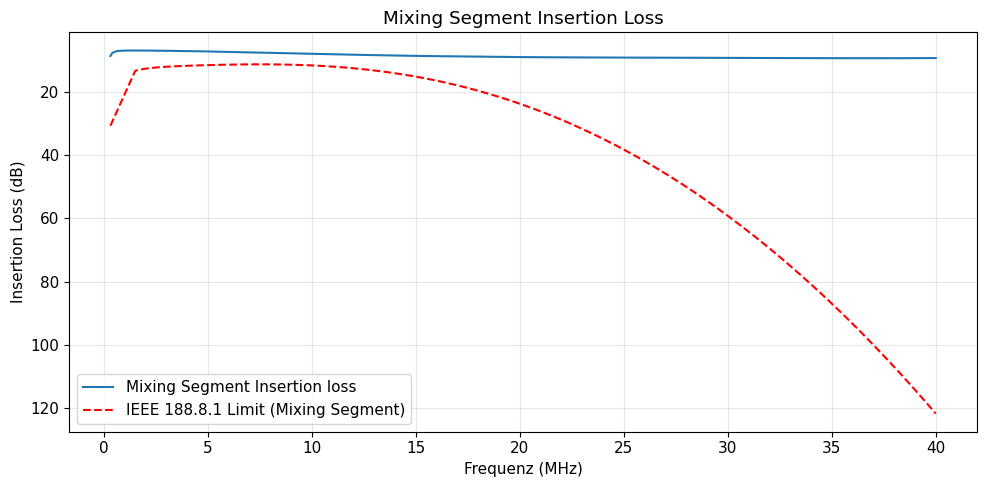

Mixing Segment 188-3: ✓  


In [7]:
from spmd_reflection.postprocess.masks import mixing_segment_il_mask


fig, ax = plt.subplots()

ms_il_limit = mixing_segment_il_mask(freqs_hz)

ax.plot(freqs_mhz, results.il_ms_db, label="Mixing Segment Insertion loss")
ax.plot(freqs_mhz, ms_il_limit, "r--", label="IEEE 188.8.1 Limit (Mixing Segment)")
ax.set_xlabel("Frequenz (MHz)")
ax.set_ylabel("Insertion Loss (dB)")
ax.set_title("Mixing Segment Insertion Loss")
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

ok_188_3 = check_ms_il(freqs_hz,results.il_ms_db)
print(f"Mixing Segment 188-3: {'✓' if ok_188_3[:].all() else '✗'}  ")


In [8]:
print("=" * 50)
print("KONFORMITÄTS-ZUSAMMENFASSUNG")
print("=" * 50)

checks = {
    "TCI IL (188-5)":  check_tci_il(freqs_hz, results.il_tci_db),
    "TCI RL (188-6)":  check_tci_rl(freqs_hz, results.rl_tci_db),
    "MPI IL (189-2)":  check_mpi_il(freqs_hz, results.il_tci_db),
    "MPI RL (189-1)":  check_mpi_rl(freqs_hz, results.rl_tci_db)}

for check_name, conformant in checks.items():
    for i in range(n_drops):
        status = "PASS ✓" if conformant[:, i].all() else "FAIL ✗"
        print(f"  Drop {i+1} – {check_name}: {status}")
    print()

ms_il_conformant = check_ms_il(freqs_hz, results.il_ms_db)
status = "PASS ✓" if ms_il_conformant[:].all() else "FAIL ✗"
print(f"  Mixing Segment IL (188-3): {status}")

KONFORMITÄTS-ZUSAMMENFASSUNG
  Drop 1 – TCI IL (188-5): FAIL ✗
  Drop 2 – TCI IL (188-5): FAIL ✗
  Drop 3 – TCI IL (188-5): FAIL ✗

  Drop 1 – TCI RL (188-6): FAIL ✗
  Drop 2 – TCI RL (188-6): FAIL ✗
  Drop 3 – TCI RL (188-6): FAIL ✗

  Drop 1 – MPI IL (189-2): FAIL ✗
  Drop 2 – MPI IL (189-2): FAIL ✗
  Drop 3 – MPI IL (189-2): FAIL ✗

  Drop 1 – MPI RL (189-1): PASS ✓
  Drop 2 – MPI RL (189-1): PASS ✓
  Drop 3 – MPI RL (189-1): PASS ✓

  Mixing Segment IL (188-3): PASS ✓
